In [1]:
import sys

sys.path.append("..")
from src.data import load_data,split_data

df = load_data("../data/housing.csv")
X_train_raw, X_test_raw, y_train, y_test = split_data(df)

In [2]:
from src.preprocess import fill_missing_bedrooms

X_train_clean, X_test_clean = fill_missing_bedrooms(
    X_train_raw,
    X_test_raw
)

In [3]:
from src.preprocess import encode_ocean_proximity

X_train_encoded, X_test_encoded = encode_ocean_proximity(
    X_train_clean,
    X_test_clean
)

In [4]:
from src.preprocess import add_rooms_per_household

X_train_features, X_test_features = add_rooms_per_household(
    X_train_encoded,
    X_test_encoded
)

In [5]:
from src.train import train_random_forest

rf_model = train_random_forest(
    X_train_features,
    y_train
)

y_rf_predict = rf_model.predict(X_test_features)


In [6]:
from src.metrics import evaluate_regression

mae, rmse, r2 = evaluate_regression(
    y_test,
    y_rf_predict
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 31579.534904636508
RMSE: 48758.58746271507
R²: 0.8185757354508766


In [7]:
from src.preprocess import add_geo_polynomial_features

X_train_linear, X_test_linear = add_geo_polynomial_features(
    X_train_features,
    X_test_features
)

In [8]:
linear_columns_to_scale = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "latitude^2",
    "latitude longitude",
    "longitude^2",
]

from src.preprocess import standardize_linear_features

X_train_linear_scaled, X_test_linear_scaled = standardize_linear_features(
    X_train_linear,
    X_test_linear,
    linear_columns_to_scale
)

In [9]:
from src.train import train_linear_regression

linear_model = train_linear_regression(
    X_train_linear_scaled,
    y_train
)

linear_predict = linear_model.predict(
    X_test_linear_scaled
)

In [10]:
linear_mae, linear_rmse, linear_r2 = evaluate_regression(
    y_test,
    linear_predict
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 49449.58978431609
RMSE: 68842.63426380655
R²: 0.6383336522356321


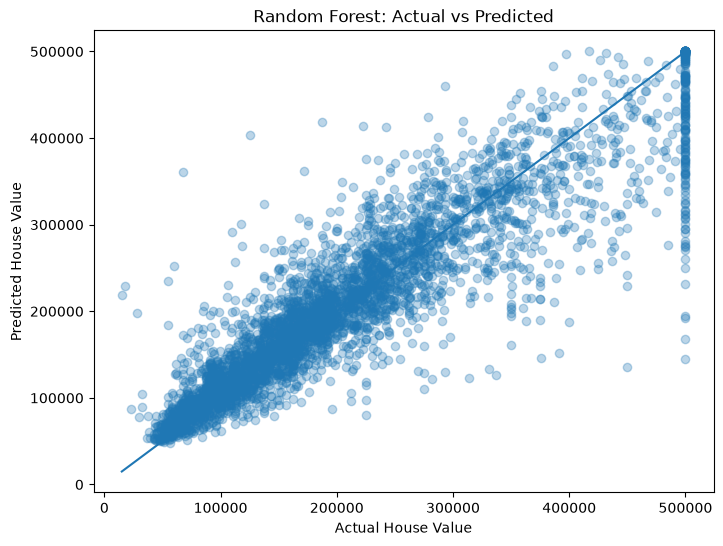

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_rf_predict,
    alpha=0.3
)

min_value = min(y_test.min(), y_rf_predict.min())
max_value = max(y_test.max(), y_rf_predict.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

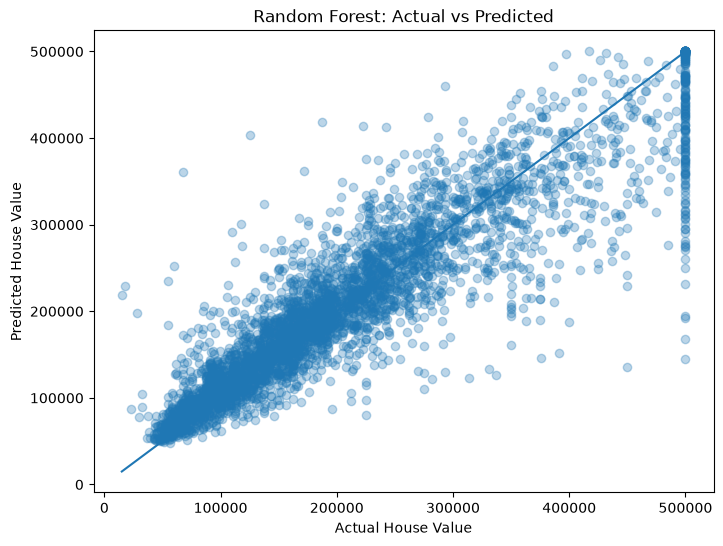

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_rf_predict,
    alpha=0.3
)

min_value = min(y_test.min(), y_rf_predict.min())
max_value = max(y_test.max(), y_rf_predict.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Random Forest: Actual vs Predicted")

plt.show()